Kelompok 4 PBL, Anggota Kelompok :
1. Muhammad Afiq Firdaus
2. Kartika Tri Juliana
3. Lovelyta Sekarayu Krisdiyanti
4. Dahniar Davina

**Analisis Perbandingan Penggunaan Metode Simple Additive Weighting (SAW) dan Evaluation Based On Distance From Average Solution (EDAS)**

In [ ]:
import pandas as pd
import numpy as np

# Memuat dataset
df = pd.read_csv('StudentPerformanceFactors.csv')

# Seleksi fitur yang relevan
selected_cols = [
    'Hours_Studied', 'Parental_Involvement', 'Access_to_Resources',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Tutoring_Sessions', 'Learning_Disabilities'
]
df_model = df[selected_cols].copy().dropna()

# Transformasi Data Kategorikal ke Numerik (Skala Likert)
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_model['Parental_Involvement'] = df_model['Parental_Involvement'].map(mapping)
df_model['Access_to_Resources'] = df_model['Access_to_Resources'].map(mapping)
df_model['Motivation_Level'] = df_model['Motivation_Level'].map(mapping)
df_model['Learning_Disabilities'] = df_model['Learning_Disabilities'].map({'No': 0, 'Yes': 1})

# Bobot kriteria (Total = 1.0)
weights = {
    'Hours_Studied': 0.20, 'Parental_Involvement': 0.10, 'Access_to_Resources': 0.10,
    'Sleep_Hours': 0.10, 'Previous_Scores': 0.25, 'Motivation_Level': 0.15,
    'Tutoring_Sessions': 0.05, 'Learning_Disabilities': 0.05
}

# Jenis kriteria (1 = Benefit, 0 = Cost)
is_benefit = {
    'Hours_Studied': 1, 'Parental_Involvement': 1, 'Access_to_Resources': 1,
    'Sleep_Hours': 1, 'Previous_Scores': 1, 'Motivation_Level': 1,
    'Tutoring_Sessions': 1, 'Learning_Disabilities': 0
}

Implementasi Metode Simple Additive Weighting (SAW)

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

# ==========================================
# 1. LOAD DAN PREPROCESSING DATA
# ==========================================
# Mengunggah data dan membersihkan baris yang kosong
df = pd.read_csv('StudentPerformanceFactors.csv')
selected_cols = [
    'Hours_Studied', 'Parental_Involvement', 'Access_to_Resources',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Tutoring_Sessions', 'Learning_Disabilities'
]
df_clean = df[selected_cols].dropna().copy()

# Transformasi Kategorikal ke Numerik (Skala Ordinal)
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_clean['Parental_Involvement'] = df_clean['Parental_Involvement'].map(mapping)
df_clean['Access_to_Resources'] = df_clean['Access_to_Resources'].map(mapping)
df_clean['Motivation_Level'] = df_clean['Motivation_Level'].map(mapping)
# Disabilitas dipetakan sebagai: 0 (Tidak ada hambatan) dan 1 (Ada hambatan)
df_clean['Learning_Disabilities'] = df_clean['Learning_Disabilities'].map({'No': 0, 'Yes': 1})


# ==========================================
# 2. KONFIGURASI BOBOT DAN KRITERIA
# ==========================================
# Bobot tingkat kepentingan kriteria (Total = 1.0)
weights = pd.Series({
    'Hours_Studied': 0.20, 'Parental_Involvement': 0.10, 'Access_to_Resources': 0.10,
    'Sleep_Hours': 0.10, 'Previous_Scores': 0.25, 'Motivation_Level': 0.15,
    'Tutoring_Sessions': 0.05, 'Learning_Disabilities': 0.05
})

# Jenis kriteria: 1 untuk Benefit (Makin besar makin baik), 0 untuk Cost (Makin kecil makin baik)
is_benefit = {
    'Hours_Studied': 1, 'Parental_Involvement': 1, 'Access_to_Resources': 1,
    'Sleep_Hours': 1, 'Previous_Scores': 1, 'Motivation_Level': 1,
    'Tutoring_Sessions': 1, 'Learning_Disabilities': 0
}


# ==========================================
# 3. PERHITUNGAN METODE SAW (NORMALISASI)
# ==========================================
df_saw = df_clean[selected_cols].copy()

for col in selected_cols:
    if is_benefit[col] == 1:
        # Rumus Benefit: Nilai / Nilai Maksimal
        df_saw[col] = df_saw[col] / df_saw[col].max()
    else:
        # Rumus Cost: Nilai Minimal / Nilai
        min_val = df_saw[col].min()
        # Penanganan khusus pembagian dengan nol (karena nilai No = 0)
        # Jika nilai = 0 (Terbaik), skor otomatis 1. Jika nilai = 1, skornya 0/1 = 0 (Terburuk).
        df_saw[col] = df_saw[col].apply(lambda x: min_val / x if x != 0 else 1.0)

# Menghitung Skor Akhir SAW (Penjumlahan Terbobot)
df_clean['SAW_Score'] = (df_saw * weights).sum(axis=1)


# ==========================================
# 4. LOGIKA REKOMENDASI PERSONAL
# ==========================================
# Kita gunakan rata-rata awal sebagai ambang batas (threshold) untuk rekomendasi
av = df_clean[selected_cols].mean()

def generate_recom(row):
    recoms = []
    # Analisis Kelemahan: Jam Belajar
    if row['Hours_Studied'] < av['Hours_Studied']:
        recoms.append("Teknik Pomodoro: Durasi 25 menit fokus untuk meningkatkan jam belajar harian.")
    # Analisis Kelemahan: Riwayat Nilai
    if row['Previous_Scores'] < av['Previous_Scores']:
        recoms.append("Metode Feynman: Jelaskan materi ke orang lain untuk menutup celah pemahaman dasar.")
    # Analisis Kelemahan: Motivasi
    if row['Motivation_Level'] <= 1:
        recoms.append("Self-Reward System: Buat target kecil dan berikan apresiasi diri setiap target tercapai.")
    # Analisis Kelemahan: Akses Sumber Daya
    if row['Access_to_Resources'] <= 1:
        recoms.append("Belajar Kelompok: Pinjam catatan atau berkolaborasi dengan teman yang memiliki sumber daya lebih.")

    # Kembalikan maksimal 2 rekomendasi saja agar lebih fokus
    return recoms[:2]

df_clean['Rekomendasi'] = df_clean.apply(generate_recom, axis=1)

# Penentuan Risiko: Misalnya kita anggap skor SAW di bawah 0.65 sebagai risiko tinggi
df_clean['Status_Risiko'] = df_clean['SAW_Score'].apply(lambda x: 'Tinggi' if x < 0.65 else 'Rendah')

# Menampilkan 10 Siswa dengan Skor SAW Terendah (Risiko Akademik Paling Tinggi)
print("--- HASIL ANALISIS RISIKO DAN REKOMENDASI (SAW) ---")
print("Menampilkan 10 siswa dengan risiko tertinggi yang membutuhkan intervensi segera:\n")
display(df_clean[['SAW_Score', 'Status_Risiko', 'Rekomendasi']].sort_values(by='SAW_Score').head(10))

--- HASIL ANALISIS RISIKO DAN REKOMENDASI (SAW) ---
Menampilkan 10 siswa dengan risiko tertinggi yang membutuhkan intervensi segera:



,SAW_Score,Status_Risiko,Rekomendasi
5387,0.397500,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
5025,0.406591,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
4811,0.417159,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
6201,0.419508,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
5749,0.429053,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
3454,0.429091,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
283,0.429091,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
2591,0.431439,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
2362,0.441667,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...
6453,0.442727,Tinggi,[Teknik Pomodoro: Durasi 25 menit fokus untuk ...


Implementasi Metode Evaluation Based On Distance From Average Solution (EDAS)

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD DAN PREPROCESSING DATA
# Mengunggah data dan membersihkan baris yang kosong [cite: 517]
df = pd.read_csv('StudentPerformanceFactors.csv')
selected_cols = [
    'Hours_Studied', 'Parental_Involvement', 'Access_to_Resources',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Tutoring_Sessions', 'Learning_Disabilities'
]
df_clean = df[selected_cols].dropna().copy()

# Transformasi Kategorikal ke Numerik agar dapat dihitung secara matematis [cite: 57, 102]
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_clean['Parental_Involvement'] = df_clean['Parental_Involvement'].map(mapping)
df_clean['Access_to_Resources'] = df_clean['Access_to_Resources'].map(mapping)
df_clean['Motivation_Level'] = df_clean['Motivation_Level'].map(mapping)
df_clean['Learning_Disabilities'] = df_clean['Learning_Disabilities'].map({'No': 0, 'Yes': 1})

# 2. KONFIGURASI BOBOT DAN KRITERIA
# Bobot ditentukan berdasarkan tingkat kepentingan terhadap performa akademik [cite: 41, 88]
weights = pd.Series({
    'Hours_Studied': 0.20, 'Parental_Involvement': 0.10, 'Access_to_Resources': 0.10,
    'Sleep_Hours': 0.10, 'Previous_Scores': 0.25, 'Motivation_Level': 0.15,
    'Tutoring_Sessions': 0.05, 'Learning_Disabilities': 0.05
})

# Menentukan jenis kriteria: 1 untuk Benefit (Manfaat), 0 untuk Cost (Biaya) [cite: 32, 113]
is_benefit = {
    'Hours_Studied': 1, 'Parental_Involvement': 1, 'Access_to_Resources': 1,
    'Sleep_Hours': 1, 'Previous_Scores': 1, 'Motivation_Level': 1,
    'Tutoring_Sessions': 1, 'Learning_Disabilities': 0
}

# 3. PERHITUNGAN METODE EDAS
# Langkah 1: Menghitung Nilai Solusi Rata-rata (AV) [cite: 325, 408]
av = df_clean.mean()

# Langkah 2: Menghitung PDA dan NDA [cite: 332, 335, 424]
pda = pd.DataFrame(index=df_clean.index, columns=selected_cols)
nda = pd.DataFrame(index=df_clean.index, columns=selected_cols)

for col in selected_cols:
    if is_benefit[col] == 1:
        pda[col] = (df_clean[col] - av[col]).apply(lambda x: max(0, x) / av[col])
        nda[col] = (av[col] - df_clean[col]).apply(lambda x: max(0, x) / av[col])
    else:
        pda[col] = (av[col] - df_clean[col]).apply(lambda x: max(0, x) / av[col])
        nda[col] = (df_clean[col] - av[col]).apply(lambda x: max(0, x) / av[col])

# Langkah 3: Menentukan Skor Penilaian Akhir (AS) [cite: 339, 347, 350]
sp = (pda * weights).sum(axis=1)
sn = (nda * weights).sum(axis=1)
nsp = sp / sp.max()
nsn = 1 - (sn / sn.max())
df_clean['Appraisal_Score'] = (nsp + nsn) / 2

# 4. LOGIKA REKOMENDASI PERSONAL
def generate_recom(row):
    recoms = []
    # Analisis jika jam belajar di bawah rata-rata
    if row['Hours_Studied'] < av['Hours_Studied']:
        recoms.append("Teknik Pomodoro: Fokus tinggi dalam durasi 25 menit untuk membangun konsistensi.")
    # Analisis jika riwayat nilai perlu ditingkatkan
    if row['Previous_Scores'] < av['Previous_Scores']:
        recoms.append("Metode Feynman: Jelaskan materi ke orang lain untuk memperkuat pemahaman konsep.")
    # Analisis jika motivasi rendah
    if row['Motivation_Level'] <= 1:
        recoms.append("Self-Reward System: Berikan apresiasi kecil pada diri sendiri setelah menyelesaikan target belajar.")
    # Analisis jika akses sumber daya kurang
    if row['Access_to_Resources'] <= 1:
        recoms.append("Grup Belajar: Berkolaborasi dengan teman untuk berbagi akses catatan dan materi.")

    return recoms[:2] # Memberikan 2 rekomendasi teratas

df_clean['Rekomendasi'] = df_clean.apply(generate_recom, axis=1)
df_clean['Status_Risiko'] = df_clean['Appraisal_Score'].apply(lambda x: 'Tinggi' if x < 0.5 else 'Rendah')

# Menampilkan 10 Siswa dengan Risiko Tertinggi untuk intervensi [cite: 352, 490]
print("--- HASIL ANALISIS RISIKO DAN REKOMENDASI (10 TERATAS) ---")
display(df_clean[['Appraisal_Score', 'Status_Risiko', 'Rekomendasi']].sort_values(by='Appraisal_Score').head(10))

--- HASIL ANALISIS RISIKO DAN REKOMENDASI (10 TERATAS) ---


,Appraisal_Score,Status_Risiko,Rekomendasi
5387,0.000000,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
283,0.031691,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
2591,0.042238,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
5025,0.050568,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
5749,0.054294,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
1975,0.062826,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
3274,0.066610,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
3007,0.069491,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...
5076,0.070953,Tinggi,[Metode Feynman: Jelaskan materi ke orang lain...
5125,0.074391,Tinggi,[Teknik Pomodoro: Fokus tinggi dalam durasi 25...


Logika Rekomendasi Personal
akan memberikan 2 rekomendasi spesifik berdasarkan kriteria yang paling rendah (risiko) dari masing-masing siswa.

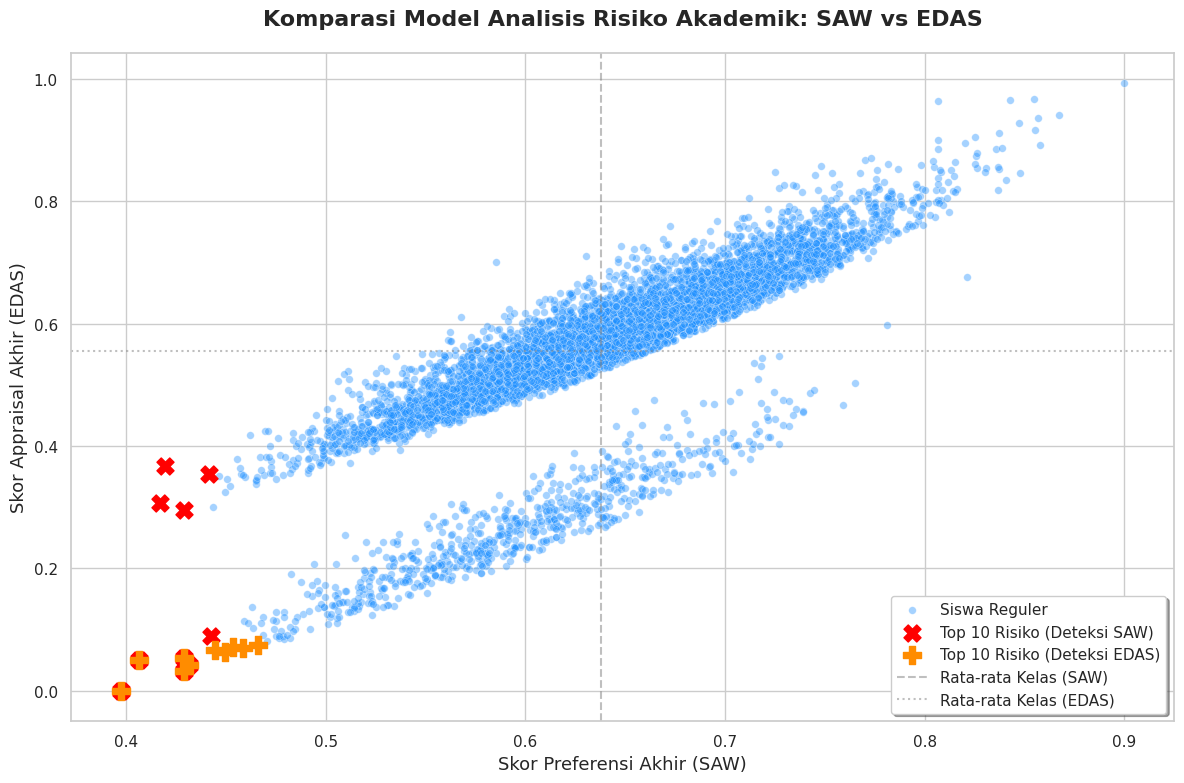

--- RINGKASAN KOMPARASI ---
Korelasi Model SAW dan EDAS : 0.7923
Irisan Deteksi Risiko Tinggi: 5 siswa sama-sama masuk dalam Top 10 di kedua metode.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DAN PREPROCESSING DATA
# ==========================================
df = pd.read_csv('StudentPerformanceFactors.csv')
selected_cols = [
    'Hours_Studied', 'Parental_Involvement', 'Access_to_Resources',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Tutoring_Sessions', 'Learning_Disabilities'
]
df_clean = df[selected_cols].dropna().copy()

mapping = {'Low': 1, 'Medium': 2, 'High': 3}
for col in ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level']:
    df_clean[col] = df_clean[col].map(mapping)
df_clean['Learning_Disabilities'] = df_clean['Learning_Disabilities'].map({'No': 0, 'Yes': 1})

# Konfigurasi Bobot dan Kriteria
weights = pd.Series({
    'Hours_Studied': 0.20, 'Parental_Involvement': 0.10, 'Access_to_Resources': 0.10,
    'Sleep_Hours': 0.10, 'Previous_Scores': 0.25, 'Motivation_Level': 0.15,
    'Tutoring_Sessions': 0.05, 'Learning_Disabilities': 0.05
})
is_benefit = {
    'Hours_Studied': 1, 'Parental_Involvement': 1, 'Access_to_Resources': 1,
    'Sleep_Hours': 1, 'Previous_Scores': 1, 'Motivation_Level': 1,
    'Tutoring_Sessions': 1, 'Learning_Disabilities': 0
}

# ==========================================
# 2. PERHITUNGAN SKOR SAW
# ==========================================
df_saw = df_clean.copy()
for col in selected_cols:
    if is_benefit[col] == 1:
        df_saw[col] = df_saw[col] / df_saw[col].max()
    else:
        min_val = df_saw[col].min()
        df_saw[col] = df_saw[col].apply(lambda x: min_val / x if x != 0 else 1.0)
df_clean['SAW_Score'] = (df_saw[selected_cols] * weights).sum(axis=1)

# ==========================================
# 3. PERHITUNGAN SKOR EDAS
# ==========================================
av = df_clean[selected_cols].mean()
pda = pd.DataFrame(index=df_clean.index, columns=selected_cols)
nda = pd.DataFrame(index=df_clean.index, columns=selected_cols)

for col in selected_cols:
    if is_benefit[col] == 1:
        pda[col] = (df_clean[col] - av[col]).apply(lambda x: max(0, x) / av[col])
        nda[col] = (av[col] - df_clean[col]).apply(lambda x: max(0, x) / av[col])
    else:
        pda[col] = (av[col] - df_clean[col]).apply(lambda x: max(0, x) / av[col])
        nda[col] = (df_clean[col] - av[col]).apply(lambda x: max(0, x) / av[col])

sp = (pda * weights).sum(axis=1)
sn = (nda * weights).sum(axis=1)
nsp = sp / sp.max()
nsn = 1 - (sn / sn.max())
df_clean['EDAS_Score'] = (nsp + nsn) / 2

# ==========================================
# 4. IDENTIFIKASI TOP 10 RISIKO TERTINGGI
# ==========================================
# Semakin rendah skor, semakin tinggi risiko akademiknya
top10_saw = df_clean.nsmallest(10, 'SAW_Score').index
top10_edas = df_clean.nsmallest(10, 'EDAS_Score').index
# ==========================================
# 5. VISUALISASI DIAGRAM (SCATTER PLOT)
# ==========================================
# Konfigurasi gaya grafik seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Plot semua data (titik biru semi-transparan)
sns.scatterplot(
    x='SAW_Score', y='EDAS_Score', data=df_clean,
    alpha=0.4, color='dodgerblue', label='Siswa Reguler', s=30
)

# Plot dan highlight Top 10 SAW (Tanda Silang Merah)
plt.scatter(
    df_clean.loc[top10_saw, 'SAW_Score'], df_clean.loc[top10_saw, 'EDAS_Score'],
    color='red', label='Top 10 Risiko (Deteksi SAW)', marker='X', s=150, zorder=5
)

# Plot dan highlight Top 10 EDAS (Tanda Plus Oranye)
plt.scatter(
    df_clean.loc[top10_edas, 'SAW_Score'], df_clean.loc[top10_edas, 'EDAS_Score'],
    color='darkorange', label='Top 10 Risiko (Deteksi EDAS)', marker='P', s=150, zorder=5
)

# Menambahkan detail pada grafik
plt.title('Komparasi Model Analisis Risiko Akademik: SAW vs EDAS', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Skor Preferensi Akhir (SAW)', fontsize=13)
plt.ylabel('Skor Appraisal Akhir (EDAS)', fontsize=13)
plt.axvline(x=df_clean['SAW_Score'].mean(), color='grey', linestyle='--', alpha=0.5, label='Rata-rata Kelas (SAW)')
plt.axhline(y=df_clean['EDAS_Score'].mean(), color='grey', linestyle=':', alpha=0.5, label='Rata-rata Kelas (EDAS)')

# Menampilkan legenda
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

# Menampilkan grafik di Google Colab
plt.tight_layout()
plt.show()

# ==========================================
# 6. ANALISIS KORELASI SEDERHANA (Tampil di output text)
# ==========================================
korelasi = df_clean[['SAW_Score', 'EDAS_Score']].corr().iloc[0,1]
overlap = len(set(top10_saw).intersection(set(top10_edas)))

print(f"--- RINGKASAN KOMPARASI ---")
print(f"Korelasi Model SAW dan EDAS : {korelasi:.4f}")
print(f"Irisan Deteksi Risiko Tinggi: {overlap} siswa sama-sama masuk dalam Top 10 di kedua metode.")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from IPython.display import display

# ==========================================
# 1. LOAD & PREPROCESSING DATA
# ==========================================
df = pd.read_csv('StudentPerformanceFactors.csv')
selected_cols = [
    'Hours_Studied', 'Parental_Involvement', 'Access_to_Resources',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Tutoring_Sessions', 'Learning_Disabilities'
]
df_clean = df[selected_cols].dropna().copy()

mapping = {'Low': 1, 'Medium': 2, 'High': 3}
for col in ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level']:
    df_clean[col] = df_clean[col].map(mapping)
df_clean['Learning_Disabilities'] = df_clean['Learning_Disabilities'].map({'No': 0, 'Yes': 1})

# Bobot dan Benefit/Cost
weights = pd.Series({
    'Hours_Studied': 0.20, 'Parental_Involvement': 0.10, 'Access_to_Resources': 0.10,
    'Sleep_Hours': 0.10, 'Previous_Scores': 0.25, 'Motivation_Level': 0.15,
    'Tutoring_Sessions': 0.05, 'Learning_Disabilities': 0.05
})
is_benefit = {
    'Hours_Studied': 1, 'Parental_Involvement': 1, 'Access_to_Resources': 1,
    'Sleep_Hours': 1, 'Previous_Scores': 1, 'Motivation_Level': 1,
    'Tutoring_Sessions': 1, 'Learning_Disabilities': 0
}

# ==========================================
# 2. PERHITUNGAN SKOR & PERANKINGAN SAW
# ==========================================
df_saw = df_clean.copy()
for col in selected_cols:
    if is_benefit[col] == 1:
        df_saw[col] = df_saw[col] / df_saw[col].max()
    else:
        min_val = df_saw[col].min()
        df_saw[col] = df_saw[col].apply(lambda x: min_val / x if x != 0 else 1.0)

df_clean['SAW_Score'] = (df_saw[selected_cols] * weights).sum(axis=1)
# Ranking SAW (1 = Skor terendah/Risiko tertinggi)
df_clean['SAW_Rank'] = df_clean['SAW_Score'].rank(ascending=True, method='min')

# ==========================================
# 3. PERHITUNGAN SKOR & PERANKINGAN EDAS
# ==========================================
av = df_clean[selected_cols].mean()
pda = pd.DataFrame(index=df_clean.index, columns=selected_cols)
nda = pd.DataFrame(index=df_clean.index, columns=selected_cols)

for col in selected_cols:
    if is_benefit[col] == 1:
        pda[col] = (df_clean[col] - av[col]).apply(lambda x: max(0, x) / av[col])
        nda[col] = (av[col] - df_clean[col]).apply(lambda x: max(0, x) / av[col])
    else:
        pda[col] = (av[col] - df_clean[col]).apply(lambda x: max(0, x) / av[col])
        nda[col] = (df_clean[col] - av[col]).apply(lambda x: max(0, x) / av[col])

sp = (pda * weights).sum(axis=1)
sn = (nda * weights).sum(axis=1)
nsp = sp / sp.max()
nsn = 1 - (sn / sn.max())

df_clean['EDAS_Score'] = (nsp + nsn) / 2
# Ranking EDAS (1 = Skor terendah/Risiko tertinggi)
df_clean['EDAS_Rank'] = df_clean['EDAS_Score'].rank(ascending=True, method='min')

# ==========================================
# 4. ANALISIS KORELASI PERANKINGAN (SPEARMAN)
# ==========================================
# Menghitung Korelasi Spearman untuk seluruh populasi dataset
corr_coef, p_value = spearmanr(df_clean['SAW_Rank'], df_clean['EDAS_Rank'])

print("======================================================")
print("HASIL UJI KORELASI PERINGKAT (SPEARMAN RANK CORRELATION)")
print("======================================================")
print(f"Nilai Korelasi (rho) : {corr_coef:.4f}")
print(f"P-Value              : {p_value:.4e}")
if corr_coef > 0.7:
    print("Kesimpulan           : Terdapat hubungan positif yang SANGAT KUAT antara ranking SAW dan EDAS.")
elif corr_coef > 0.4:
    print("Kesimpulan           : Terdapat hubungan positif yang SEDANG antara ranking SAW dan EDAS.")
else:
    print("Kesimpulan           : Hubungan ranking SAW dan EDAS lemah/berbeda signifikan.")
print("======================================================\n")

# ==========================================
# 5. KOMPARASI TOP 10 HASIL REKOMENDASI
# ==========================================
# Mengambil 10 siswa dengan risiko tertinggi (Rank 1-10) dari masing-masing metode
top10_saw = df_clean.nsmallest(10, 'SAW_Rank')
top10_edas = df_clean.nsmallest(10, 'EDAS_Rank')

# Menggabungkan index dari kedua top 10 (Union) untuk melihat silang rankingnya
gabungan_top_index = list(set(top10_saw.index).union(set(top10_edas.index)))

# Membuat dataframe khusus untuk membandingkan ranking mereka
df_komparasi = df_clean.loc[gabungan_top_index, ['SAW_Score', 'SAW_Rank', 'EDAS_Score', 'EDAS_Rank']].copy()

# Mengurutkan berdasarkan peringkat EDAS agar lebih mudah dibaca
df_komparasi = df_komparasi.sort_values(by='EDAS_Rank')

print("TABEL KOMPARASI RANKING (Siswa yang masuk Top 10 di SAW dan/atau EDAS):")
print("Catatan: Rank 1 berarti siswa dengan risiko paling kritis (Prioritas Utama).")
display(df_komparasi)

# Analisis Irisan (Overlap)
overlap = len(set(top10_saw.index).intersection(set(top10_edas.index)))
print(f"\nDari total 10 rekomendasi, terdapat {overlap} siswa yang SAMA PERSIS direkomendasikan oleh kedua metode.")

HASIL UJI KORELASI PERINGKAT (SPEARMAN RANK CORRELATION)
Nilai Korelasi (rho) : 0.8670
P-Value              : 0.0000e+00
Kesimpulan           : Terdapat hubungan positif yang SANGAT KUAT antara ranking SAW dan EDAS.

TABEL KOMPARASI RANKING (Siswa yang masuk Top 10 di SAW dan/atau EDAS):
Catatan: Rank 1 berarti siswa dengan risiko paling kritis (Prioritas Utama).


,SAW_Score,SAW_Rank,EDAS_Score,EDAS_Rank
5387,0.397500,1.0,0.000000,1.0
283,0.429091,7.0,0.031691,2.0
2591,0.431439,8.0,0.042238,3.0
5025,0.406591,2.0,0.050568,4.0
5749,0.429053,5.0,0.054294,5.0
1975,0.449318,14.0,0.062826,6.0
3274,0.444432,12.0,0.066610,7.0
3007,0.458750,23.0,0.069491,8.0
5076,0.453409,18.0,0.070953,9.0
5125,0.466061,35.0,0.074391,10.0



Dari total 10 rekomendasi, terdapat 5 siswa yang SAMA PERSIS direkomendasikan oleh kedua metode.


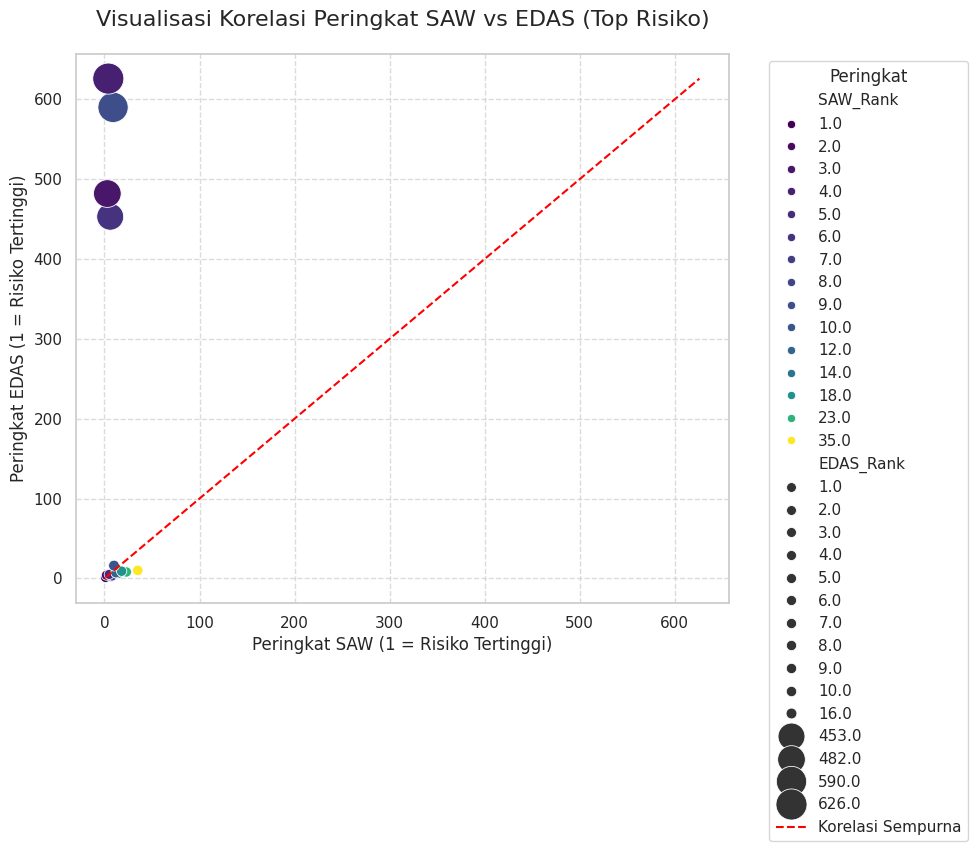

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mempersiapkan data untuk visualisasi
# df_komparasi sudah berisi siswa yang masuk Top 10 di SAW dan/atau EDAS

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='SAW_Rank', y='EDAS_Rank', data=df_komparasi,
    hue='SAW_Rank',  # Memberikan warna berdasarkan ranking SAW
    size='EDAS_Rank', # Ukuran titik berdasarkan ranking EDAS
    sizes=(50, 500), # Rentang ukuran titik
    palette='viridis', # Skema warna
    legend='full' # Menampilkan legenda ukuran dan warna
)

# Menambahkan garis diagonal untuk menunjukkan korelasi sempurna
min_rank = min(df_komparasi['SAW_Rank'].min(), df_komparasi['EDAS_Rank'].min())
max_rank = max(df_komparasi['SAW_Rank'].max(), df_komparasi['EDAS_Rank'].max())
plt.plot([min_rank, max_rank], [min_rank, max_rank], color='red', linestyle='--', label='Korelasi Sempurna')

plt.title('Visualisasi Korelasi Peringkat SAW vs EDAS (Top Risiko)', fontsize=16, pad=20)
plt.xlabel('Peringkat SAW (1 = Risiko Tertinggi)', fontsize=12)
plt.ylabel('Peringkat EDAS (1 = Risiko Tertinggi)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Peringkat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()